In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from simulation import make_points, rbf_similarity_matrix
from submodular_greedy import greedy_submodular_maximization

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

# Submodular Function Visualization (Greedy)

This notebook simulates a monotone submodular objective (facility-location style),
runs greedy maximization, and exports the selection process as a GIF animation.

In [ ]:
x = make_points(n=80, seed=42)
sim = rbf_similarity_matrix(x, sigma=1.15)
n_items = x.shape[0]
print(f"n_items={n_items}")

n_items=80


In [ ]:
k = 15
selected, gains, values = greedy_submodular_maximization(sim, k=k)
print("selected indices:", selected)
print("final F(S):", values[-1])

selected indices: [57, 11, 28, 29, 3, 21, 55, 65, 0, 76, 12, 75, 8, 31, 77]
final F(S): 74.07735090645848


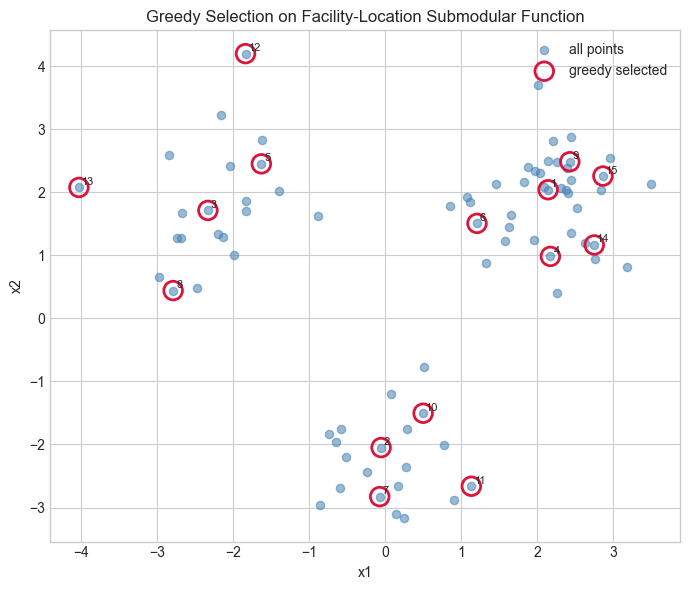

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(x[:, 0], x[:, 1], s=35, c="steelblue", alpha=0.55, label="all points")
sel = np.array(selected)
ax.scatter(
    x[sel, 0],
    x[sel, 1],
    s=180,
    facecolors="none",
    edgecolors="crimson",
    linewidths=2.0,
    label="greedy selected"
)

for rank, idx in enumerate(selected, start=1):
    ax.text(x[idx, 0] + 0.04, x[idx, 1] + 0.04, str(rank), fontsize=8)

ax.set_title("Greedy Selection on Facility-Location Submodular Function")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

In [5]:
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)
gif_path = output_dir / "submodular_greedy.gif"

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 6))

ax_l.set_title("Selection Process")
ax_l.set_xlabel("x1")
ax_l.set_ylabel("x2")
ax_l.scatter(x[:, 0], x[:, 1], s=35, c="lightgray", alpha=0.7)

ax_r.set_title("Objective and Marginal Gain")
ax_r.set_xlabel("step")
ax_r.set_ylabel("value")

value_line, = ax_r.plot([], [], color="royalblue", marker="o", label="F(S_t)")
gain_line, = ax_r.plot([], [], color="darkorange", marker="s", label="gain_t")
ax_r.legend(loc="best")

all_x1 = x[:, 0]
all_x2 = x[:, 1]
ax_l.set_xlim(all_x1.min() - 0.8, all_x1.max() + 0.8)
ax_l.set_ylim(all_x2.min() - 0.8, all_x2.max() + 0.8)

ymax = max(values + gains) * 1.10
ax_r.set_xlim(0, k)
ax_r.set_ylim(0, ymax)


def update(frame: int):
    # frame=0 is initial state, then 1..k show incremental selection
    ax_l.cla()
    ax_l.set_title(f"Selection Process (step={frame}/{k})")
    ax_l.set_xlabel("x1")
    ax_l.set_ylabel("x2")
    ax_l.set_xlim(all_x1.min() - 0.8, all_x1.max() + 0.8)
    ax_l.set_ylim(all_x2.min() - 0.8, all_x2.max() + 0.8)
    ax_l.scatter(x[:, 0], x[:, 1], s=35, c="lightgray", alpha=0.7)

    if frame > 0:
        current_sel = selected[:frame]
        sidx = np.array(current_sel)
        ax_l.scatter(
            x[sidx, 0],
            x[sidx, 1],
            s=180,
            facecolors="none",
            edgecolors="crimson",
            linewidths=2.0,
        )
        for rank, idx in enumerate(current_sel, start=1):
            ax_l.text(x[idx, 0] + 0.04, x[idx, 1] + 0.04, str(rank), fontsize=8)

    xs = np.arange(frame + 1)
    ys_val = values[: frame + 1]
    ys_gain = [0.0] + gains[:frame]
    value_line.set_data(xs, ys_val)
    gain_line.set_data(xs, ys_gain)
    return (value_line, gain_line)


anim = FuncAnimation(fig, update, frames=np.arange(0, k + 1), interval=650, blit=False)
anim.save(gif_path, writer=PillowWriter(fps=1.5))
plt.close(fig)

print(f"saved gif: {gif_path}")

saved gif: outputs/submodular_greedy.gif
